# 01 — Entropie et pureté : de von Neumann à Shannon

L'analogie du projet repose sur une affirmation précise, et il faut commencer par
la vérifier : **ce n'est pas la multiplicité des possibilités qui produit de
l'entropie, c'est la perte de cohérence entre elles.**

Un chat de Schrödinger vivant *et* mort est dans un état **pur** : son entropie de
von Neumann est nulle. Une population où chacun garde plusieurs opinions ouvertes
n'est pas encore désordonnée. Le désordre naît de l'interaction avec
l'environnement, qui détruit les termes croisés de la matrice de densité.

Ce notebook mesure les deux entropies, montre qu'elles décrivent le même phénomène,
et définit l'**Indice de Diversité Exposée (IDE)** sur cette base.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ide.entropy import (
    label_diversity_index,
    shannon_entropy,
    von_neumann_entropy,
)
from ide.plotting import PALETTE, save_figure, use_project_style

use_project_style()
rng = np.random.default_rng(0)

## La superposition est pure, le mélange ne l'est pas

On construit une famille de matrices de densité à deux niveaux paramétrée par la
**cohérence** $c$ :

$$\rho(c) = \frac{1}{2}\begin{pmatrix} 1 & c \\ c & 1 \end{pmatrix}$$

* $c = 1$ — superposition cohérente $(|0\rangle + |1\rangle)/\sqrt{2}$, état **pur**.
* $c = 0$ — mélange statistique classique, entropie **maximale**.

La décohérence est le trajet de $c = 1$ vers $c = 0$. Les populations diagonales,
elles, ne changent pas d'un bout à l'autre : c'est bien la cohérence, et non la
distribution des résultats de mesure, qui porte l'information perdue.

In [2]:
coherence = np.linspace(1.0, 0.0, 201)
quantum_entropy = np.array(
    [von_neumann_entropy(0.5 * np.array([[1.0, c], [c, 1.0]])) for c in coherence]
)

print(f"c = 1 (superposition pure)  : S = {quantum_entropy[0]:.3e} nats")
print(f"c = 0 (mélange décohéré)    : S = {quantum_entropy[-1]:.6f} nats  (ln 2 = {np.log(2):.6f})")

c = 1 (superposition pure)  : S = 0.000e+00 nats
c = 0 (mélange décohéré)    : S = 0.693147 nats  (ln 2 = 0.693147)


## Le pendant social : fermeture du fil et effondrement de l'IDE

Côté population, on paramètre un fil d'actualité par la **part $f$ du point de vue
dominant**, le reste étant réparti sur trois autres points de vue. C'est la fermeture
progressive d'une bulle de filtres.

L'IDE rapporte l'entropie de Shannon du fil à son maximum théorique $\log_2 k$ :

$$\mathrm{IDE} = \frac{H(X)}{\log_2 k}$$

Cette normalisation est ce qui rend l'index utilisable par un régulateur : un seuil
exprimé en pourcentage se compare entre plateformes, un seuil en bits ne se compare
à rien.

In [3]:
dominance = np.linspace(0.25, 1.0, 201)
social_entropy = np.array(
    [shannon_entropy([f, *([(1.0 - f) / 3.0] * 3)]) for f in dominance]
)
index = social_entropy / np.log2(4)

# Vérification directe sur des fils d'actualité explicites.
for feed, label in [
    (["complot", "factuel", "opinion", "satire"] * 5, "fil équilibré"),
    (["complot"] * 12 + ["factuel", "opinion", "satire"], "fil qui se referme"),
    (["complot"] * 20, "bulle gelée"),
]:
    print(f"{label:20s} IDE = {label_diversity_index(feed, catalogue_size=4):.3f}")

fil équilibré        IDE = 1.000
fil qui se referme   IDE = 0.519
bulle gelée          IDE = 0.000


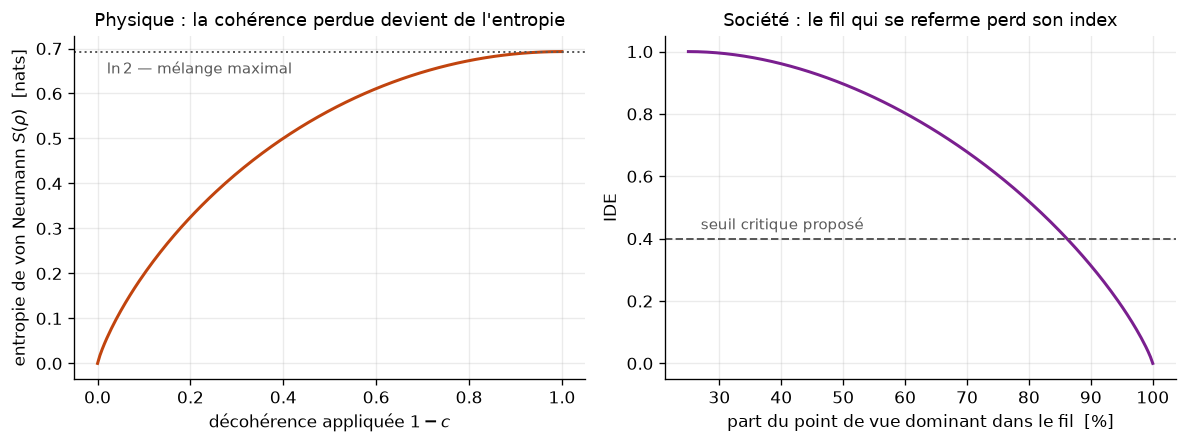

In [4]:
figure, (left, right) = plt.subplots(1, 2, figsize=(10, 3.8))

left.plot(1.0 - coherence, quantum_entropy, color=PALETTE["disorder"])
left.axhline(np.log(2), color=PALETTE["neutral"], linestyle=":", linewidth=1.2)
left.text(0.02, np.log(2) * 0.93, r"$\ln 2$ — mélange maximal", color=PALETTE["neutral"], fontsize=9)
left.set_xlabel("décohérence appliquée $1 - c$")
left.set_ylabel(r"entropie de von Neumann $S(\rho)$  [nats]")
left.set_title("Physique : la cohérence perdue devient de l'entropie")

right.plot(dominance * 100, index, color=PALETTE["field"])
right.axhline(0.4, color=PALETTE["neutral"], linestyle="--", linewidth=1.2)
right.text(27, 0.43, "seuil critique proposé", color=PALETTE["neutral"], fontsize=9)
right.set_xlabel("part du point de vue dominant dans le fil  [%]")
right.set_ylabel("IDE")
right.set_title("Société : le fil qui se referme perd son index")

save_figure(figure, "fig01_entropie.png")
plt.show()

## Ce que le notebook établit

1. Une superposition cohérente a une entropie **strictement nulle** : l'analogie doit
   parler de décohérence, pas de multiplicité. C'est une précision qui protège
   l'argument (voir l'audit, point 5).
2. L'entropie de von Neumann **est** l'entropie de Shannon des valeurs propres de
   $\rho$ : les deux disciplines mesurent la même chose, ce qui justifie le pont.
3. L'IDE se comporte comme attendu — il vaut 1 sur un fil équilibré, tombe à 0 sur
   une bulle fermée, et traverse le seuil critique bien avant la fermeture complète.
   Un régulateur peut donc détecter un gel **en cours**, pas seulement constaté.